### Limpieza, asimetría y descriptivos
 

In [37]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv("e-commerce.csv")

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2510 non-null   int64  
 1   customer_id       2510 non-null   int64  
 2   channel           2510 non-null   object 
 3   region            2480 non-null   object 
 4   product_category  2510 non-null   object 
 5   units             2510 non-null   int64  
 6   unit_price        2460 non-null   float64
 7   discount_rate     2510 non-null   float64
 8   shipping_days     2451 non-null   float64
 9   customer_age      2510 non-null   int64  
 10  income_monthly    2430 non-null   float64
 11  return_flag       2510 non-null   int64  
 12  satisfaction      2510 non-null   int64  
 13  gross_revenue     2460 non-null   float64
 14  net_revenue       2460 non-null   float64
dtypes: float64(6), int64(6), object(3)
memory usage: 294.3+ KB


In [40]:
print(data.isnull().any().sum())


6


In [41]:
print(data.isnull().sum()[data.isnull().sum() > 0])

region            30
unit_price        50
shipping_days     59
income_monthly    80
gross_revenue     50
net_revenue       50
dtype: int64


In [42]:
total_missing = data.isnull().sum().sum()
total_valores = data.size
porcentaje = (total_missing / total_valores * 100).round(2)
print(f"Porcentaje total de missing values: {porcentaje}%")

Porcentaje total de missing values: 0.85%


In [43]:
print(data.duplicated().sum())

10


In [44]:
# Eliminar duplicados
data1 = data.drop_duplicates()

# Promedio de net_revenue redondeado a 2 decimales
round(data1['net_revenue'].mean(), 2)


np.float64(74.75)

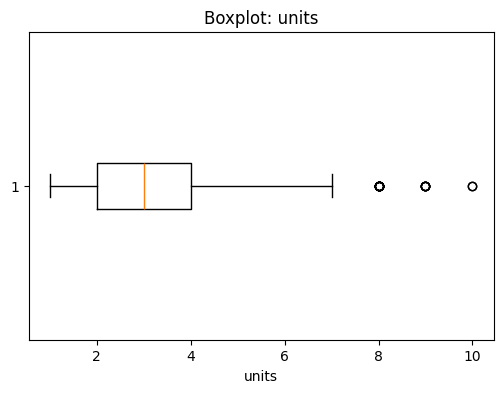

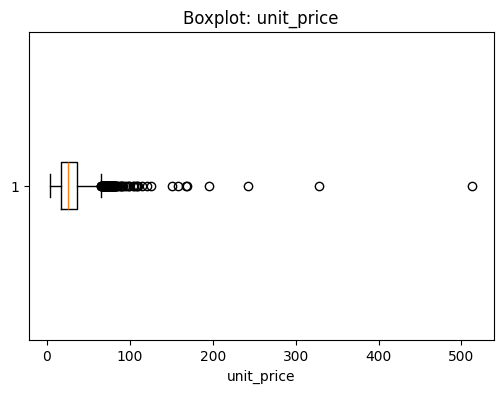

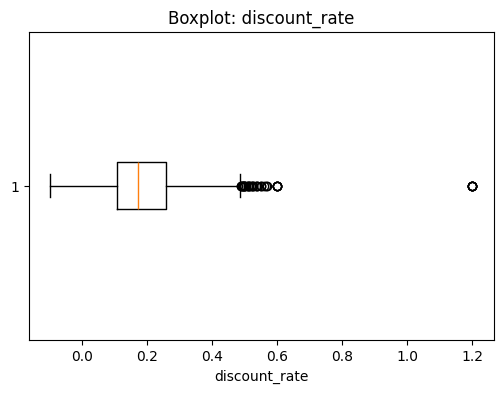

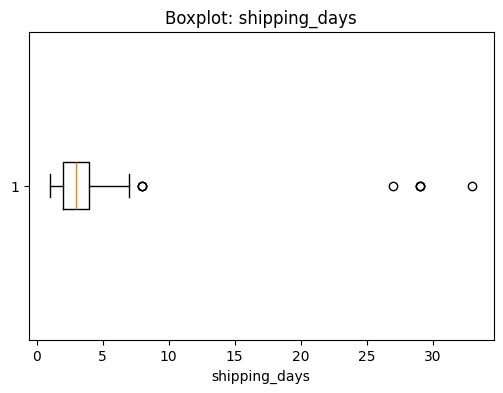

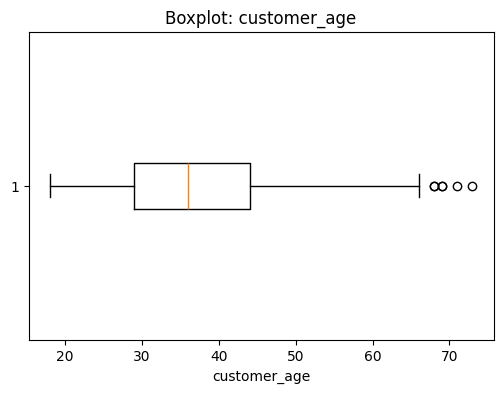

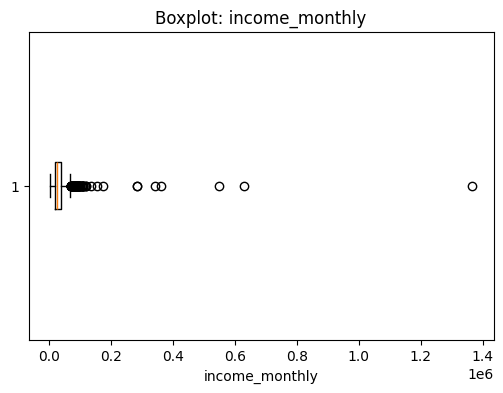

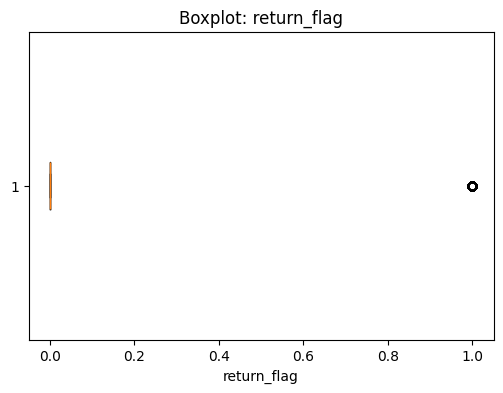

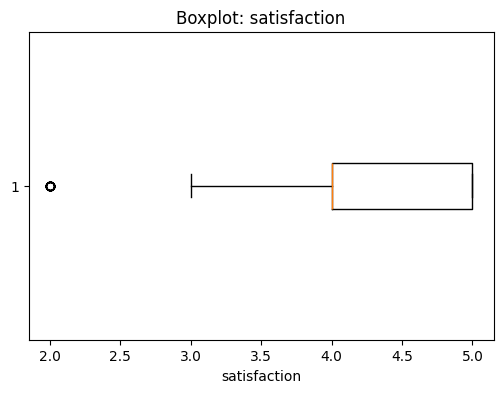

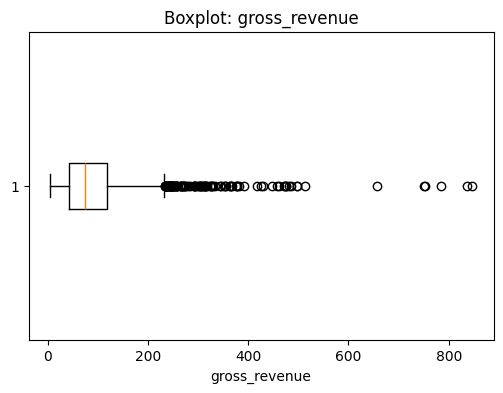

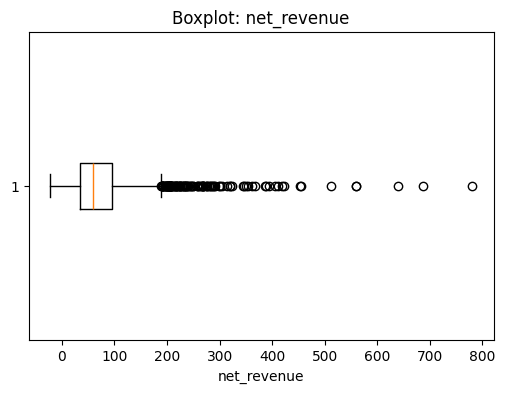

In [45]:
import matplotlib.pyplot as plt

cols = [col for col in data.columns if col not in ['order_id', 'customer_id']]
cols_num = data[cols].select_dtypes(include='number').columns

for col in cols_num:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

In [46]:
# Calcular asimetría excluyendo las variables indicadas
cols_excluir = ['order_id', 'customer_id', 'return_flag']
cols_num = data1.drop(columns=cols_excluir).select_dtypes(include='number').columns

skewness = data1[cols_num].skew().round(2)
print(skewness)

# Asimetría fuerte: valor absoluto > 1
asimetria_fuerte = skewness[skewness.abs() > 1]
print(f"\nVariables con asimetría fuerte: {len(asimetria_fuerte)}")
print(asimetria_fuerte)

units              0.71
unit_price         7.75
discount_rate      1.89
shipping_days      6.45
customer_age       0.20
income_monthly    21.07
satisfaction      -0.27
gross_revenue      3.13
net_revenue        3.18
dtype: float64

Variables con asimetría fuerte: 6
unit_price         7.75
discount_rate      1.89
shipping_days      6.45
income_monthly    21.07
gross_revenue      3.13
net_revenue        3.18
dtype: float64


In [47]:
# Conteo de outliers por variable usando IQR
cols_excluir = ['order_id', 'customer_id', 'return_flag']
numeric_cols = data1.drop(columns=cols_excluir).select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = data1[col].quantile(0.25)
    Q3 = data1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data1[(data1[col] < lower) | (data1[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers")

units: 22 outliers
unit_price: 89 outliers
discount_rate: 37 outliers
shipping_days: 8 outliers
customer_age: 6 outliers
income_monthly: 104 outliers
satisfaction: 20 outliers
gross_revenue: 111 outliers
net_revenue: 117 outliers


In [48]:
#Conteo de outliers en la variable income_monthly usando IQR
col = 'income_monthly'
Q1 = data1[col].quantile(0.25)
Q3 = data1[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data1[(data1[col] < lower) | (data1[col] > upper)].shape[0]
print(f"{col}: {outliers} outliers")



income_monthly: 104 outliers


In [49]:
data_cleaned=data1.copy()

In [50]:
# Eliminamos los outliers de la variable income_monthly utilizando el método del rango intercuartílico (IQR)

Q1 = data_cleaned['income_monthly'].quantile(0.25)
Q3 = data_cleaned['income_monthly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data_cleaned_no_outliers = data_cleaned[(data_cleaned['income_monthly'] >= lower_bound) & (data_cleaned['income_monthly'] <= upper_bound)]

data_cleaned_no_outliers['income_monthly'].median().round(2)

np.float64(25644.1)

In [78]:
# Eliminamos los ouliers del resto de variables numéricas utilizando el método del rango intercuartílico (IQR), excluyendo "customer_id", "order_id" y "return_flag"
data_cleaned_no_outliers_all = data_cleaned_no_outliers.copy()
for col in numeric_cols:
    if col not in ['income_monthly']:
        Q1 = data_cleaned_no_outliers_all[col].quantile(0.25)
        Q3 = data_cleaned_no_outliers_all[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data_cleaned_no_outliers_all = data_cleaned_no_outliers_all[
            (data_cleaned_no_outliers_all[col] >= lower_bound) & 
            (data_cleaned_no_outliers_all[col] <= upper_bound)
        ]
# Conteo de observaciones después de eliminar outliers
total_observations_no_outliers_all = len(data_cleaned_no_outliers_all)
print(f"Total de observaciones después de eliminar outliers en todas las variables numéricas: {total_observations_no_outliers_all}")

Total de observaciones después de eliminar outliers en todas las variables numéricas: 1693


In [79]:
missing = data_cleaned_no_outliers_all.isnull().sum()
print(missing[missing > 0])
print(f"\nVariables con missing values: {(missing > 0).sum()}")

region    24
dtype: int64

Variables con missing values: 1


In [80]:
data_cleaned_no_outliers_all['region'].mode()

0    Norte
Name: region, dtype: object

In [76]:
# Imputar mediana en income_monthly
data_cleaned_no_outliers_all['income_monthly'] = data_cleaned_no_outliers_all['income_monthly'].fillna(data_cleaned_no_outliers['income_monthly'].median())

# Imputar moda en region
data_cleaned_no_outliers_all['region'] = data_cleaned_no_outliers_all['region'].fillna(data_cleaned_no_outliers_all['region'].mode()[0])

# Verificar que no haya missing values
print(data_cleaned_no_outliers_all.isnull().sum())

# Porcentaje de observaciones perdidas
obs_original = len(data)
obs_final = len(data_cleaned_no_outliers_all)
pct_perdidas = round((obs_original - obs_final) / obs_original * 100, 2)
print(f"\nObservaciones originales: {obs_original}")
print(f"Observaciones finales: {obs_final}")
print(f"Porcentaje perdido: {pct_perdidas}%")

order_id            0
customer_id         0
channel             0
region              0
product_category    0
units               0
unit_price          0
discount_rate       0
shipping_days       0
customer_age        0
income_monthly      0
return_flag         0
satisfaction        0
gross_revenue       0
net_revenue         0
dtype: int64

Observaciones originales: 2510
Observaciones finales: 1988
Porcentaje perdido: 20.8%


In [55]:
data_cleaned_no_outliers_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1693 entries, 0 to 2497
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1693 non-null   int64  
 1   customer_id       1693 non-null   int64  
 2   channel           1693 non-null   object 
 3   region            1693 non-null   object 
 4   product_category  1693 non-null   object 
 5   units             1693 non-null   int64  
 6   unit_price        1693 non-null   float64
 7   discount_rate     1693 non-null   float64
 8   shipping_days     1693 non-null   float64
 9   customer_age      1693 non-null   int64  
 10  income_monthly    1693 non-null   float64
 11  return_flag       1693 non-null   int64  
 12  satisfaction      1693 non-null   int64  
 13  gross_revenue     1693 non-null   float64
 14  net_revenue       1693 non-null   float64
dtypes: float64(6), int64(6), object(3)
memory usage: 211.6+ KB


In [72]:
quedan=2510-1693
quedan/2510

0.3254980079681275

In [57]:
# Frecuencia de cada categoría para variables tipo objeto
cols_objeto = data_cleaned_no_outliers_all.select_dtypes(include='object').columns

for col in cols_objeto:
    print(f"\n--- {col} ---")
    print(data_cleaned_no_outliers_all[col].value_counts())


--- channel ---
channel
app            605
web            569
store          356
marketplace    163
Name: count, dtype: int64

--- region ---
region
Norte     792
Centro    576
Sur       325
Name: count, dtype: int64

--- product_category ---
product_category
Moda           452
Hogar          382
Electrónica    307
Alimentos      306
Salud          246
Name: count, dtype: int64


In [58]:
tabla = pd.crosstab(data_cleaned_no_outliers_all['region'], 
                    data_cleaned_no_outliers_all['product_category'], 
                    normalize=True) * 100

print(tabla.round(2))

product_category  Alimentos  Electrónica  Hogar   Moda  Salud
region                                                       
Centro                 5.61         6.14   8.15   8.86   5.26
Norte                  8.98         8.45  10.45  12.46   6.44
Sur                    3.48         3.54   3.96   5.38   2.84


In [59]:
tabla = pd.crosstab(data_cleaned_no_outliers_all['region'], 
                    data_cleaned_no_outliers_all['channel'], 
                    normalize='columns') * 100

print(tabla.round(2))


channel    app  marketplace  store    web
region                                   
Centro   33.06        36.81  35.11  33.57
Norte    47.60        41.72  47.19  47.10
Sur      19.34        21.47  17.70  19.33


In [60]:
# Paso 1: Categoría más frecuente
print(data_cleaned_no_outliers_all['product_category'].value_counts())

product_category
Moda           452
Hogar          382
Electrónica    307
Alimentos      306
Salud          246
Name: count, dtype: int64


In [61]:
# Paso 2: Tabla cruzada de esa categoría con channel
categoria_frecuente = data_cleaned_no_outliers_all['product_category'].mode()[0]

tabla = pd.crosstab(
    data_cleaned_no_outliers_all[data_cleaned_no_outliers_all['product_category'] == categoria_frecuente]['channel'],
    data_cleaned_no_outliers_all[data_cleaned_no_outliers_all['product_category'] == categoria_frecuente]['product_category'],
    normalize='columns') * 100

print(tabla.round(2))

product_category   Moda
channel                
app               35.62
marketplace        9.29
store             20.35
web               34.73


In [73]:
print(data_cleaned_no_outliers_all.groupby('region')['net_revenue'].mean().round(2).sort_values(ascending=False))


region
Sur       61.91
Norte     61.25
Centro    59.32
Name: net_revenue, dtype: float64


In [74]:
print(data_cleaned_no_outliers_all.groupby('region')['net_revenue'].mean().round(2).max())

61.91


In [92]:
print(data_cleaned_no_outliers.loc[data_cleaned_no_outliers['satisfaction'].idxmin(), 'customer_age'])

65


In [89]:
print(data_cleaned_no_outliers[data_cleaned_no_outliers['satisfaction'] <= 2
][['customer_age', 'satisfaction']])

      customer_age  satisfaction
113             65             2
141             18             2
645             51             2
744             23             2
1256            34             2
1349            54             2
1502            20             2
1539            20             2
1612            50             2
1766            35             2
1904            19             2
1917            66             2
1927            35             2
2015            40             2
2390            49             2
2400            40             2
2457            40             2


In [66]:
# Promedio de ventas efectivas por región en porcentaje
total = data_cleaned_no_outliers_all['net_revenue'].sum()

resultado = data_cleaned_no_outliers_all.groupby('region')['net_revenue'].mean().sort_values(ascending=False)
print(resultado)

# Porcentaje que representa cada región del total de ventas
pct = (data_cleaned_no_outliers_all.groupby('region')['net_revenue'].sum() / total * 100).sort_values(ascending=False)
print(f"\nPorcentaje del total de ventas por región:")
print(pct)

region
Sur       61.912607
Norte     61.247602
Centro    59.319944
Name: net_revenue, dtype: float64

Porcentaje del total de ventas por región:
region
Norte     47.187793
Centro    33.238285
Sur       19.573922
Name: net_revenue, dtype: float64


In [67]:
print(data_cleaned_no_outliers_all.groupby('region')['net_revenue'].mean().round(2))

region
Centro    59.32
Norte     61.25
Sur       61.91
Name: net_revenue, dtype: float64


In [68]:
missing = data_cleaned_no_outliers_all.isnull().sum()
print(missing)
print(f"\nVariables con missing values: {(missing > 0).sum()}")

order_id            0
customer_id         0
channel             0
region              0
product_category    0
units               0
unit_price          0
discount_rate       0
shipping_days       0
customer_age        0
income_monthly      0
return_flag         0
satisfaction        0
gross_revenue       0
net_revenue         0
dtype: int64

Variables con missing values: 0


In [ ]:
# Imputar mediana en income_monthly
data_cleaned_no_outliers_all['income_monthly'] = data_cleaned_no_outliers_all['income_monthly'].fillna(25664.10)

# Imputar moda en region
data_cleaned_no_outliers_all['region'] = data_cleaned_no_outliers_all['region'].fillna('Norte')

# Verificar que no haya missing values
print(data_cleaned_no_outliers_all.isnull().sum())

# Porcentaje de observaciones perdidas con la limpieza
obs_original = len(data)
obs_final = len(data_cleaned_no_outliers_all)
pct_perdidas = ((obs_original - obs_final) / obs_original) * 100
print(f"\nObservaciones originales: {obs_original}")
print(f"Observaciones finales: {obs_final}")
print(f"Porcentaje perdido: {pct_perdidas}%")

order_id            0
customer_id         0
channel             0
region              0
product_category    0
units               0
unit_price          0
discount_rate       0
shipping_days       0
customer_age        0
income_monthly      0
return_flag         0
satisfaction        0
gross_revenue       0
net_revenue         0
dtype: int64

Observaciones originales: 2510
Observaciones finales: 1693
Porcentaje perdido: 32.54980079681275%


In [82]:
discount_mean=data_cleaned_no_outliers['discount_rate'].mean().round(2)
print(discount_mean)

0.19


In [ ]:

observation_count=data_cleaned_no_outliers.shape[0]
print(observation_count)

2316
